## **Tensorflow and Keras - Load Dataset, Split Dataset, Scale Down / Normalization, Evaluate model**

In [3]:
# 1. Import Libraries

import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
# 2. Get data and split into train and test datasets
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

In [5]:
# 3. Scale down values of pixels from 0-255 to 0-1

train_images = train_images /255.0
test_images = test_images / 255.0

(60000, 28, 28)
(10000, 28, 28)
[5 0 4 ... 5 6 8]


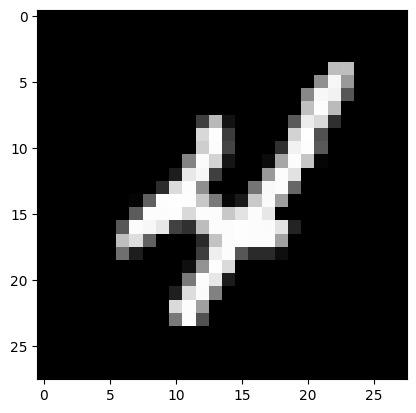

In [6]:
# 4. Visualizing data
print(train_images.shape)
print(test_images.shape)
print(train_labels)

# 5. Display first image
plt.imshow(train_images[9], cmap='gray')
plt.show()

In [7]:
# 6. Defining neural network model

my_model = tf.keras.models.Sequential()
my_model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
my_model.add(tf.keras.layers.Dense(128, activation='relu'))     #Rectified Linear Unit        #Dense layers are used to learn complex patterns in data.
my_model.add(tf.keras.layers.Dense(10, activation='softmax'))   #softmax is often used as the activation function in the output layer for classification tasks

# Compiling the model
my_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) #Adaptive Moment Estimation #sparse_categorical_crossentropy for multi-class classification

# Training the model
my_model.fit(train_images, train_labels, epochs=3)

d:\Third Year\DL\Assignments\Exp_1\newenv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9252 - loss: 0.2599
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9669 - loss: 0.1125
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9770 - loss: 0.0776


In [8]:
# Checking model accuracy on test data
val_loss, val_acc = my_model.evaluate(test_images, test_labels)
print('Test accuracy: ', val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - accuracy: 0.9740 - loss: 0.0805
Test accuracy:  0.9739999771118164


In [9]:
my_model.save('mnist_model.keras')